 # iValue_TW — 無形資本調整價值因子（intangible-adjusted B/M）

| 項目 | 內容 |
|------|------|
| **策略邏輯** | **Step1 資本化**：把被費用化的 R&D（δ=0.15）與 30% SG&A（δ=0.20）用永續盤存還原成無形資本、加回淨值 → iBook = Book + 知識資本 G + 組織資本 O；**Step2 因子**：iB/M = iBook ÷ 市價（與傳統 B/M 同尺度，越高＝相對真實資產越便宜）；**Step3 投組**：流動母體（市值≥50億）選 iB/M 前 20 檔、反波動率加權、每年 6 月再平衡。｜算法細節見 §4-D。 |
| **架構** | 財報選股架構 |
| **調倉頻率** | 年度（每年 6 月第一個交易日；持有 12 個月） |
| **股票池** | TSE/OTC 上市櫃普通股 |
| **Alpha 來源** | Arnott, Harvey, Kalesnik & Linnainmaa (2021)；Lev & Srivastava (2020)；資本化方法 Peters & Taylor (2017) |
| **資料來源** | TEJ（`get_universe`、TWN/APRCD1 via TejToolAPI、TWN/AIM1A 年度財報、TWN/AIM1AA 發布日(PIT)、IR0001 報酬指數） |

> **核心 Alpha**：R&D 與 30% SG&A 被會計費用化、不列資產 → 傳統 B/M 誤把 R&D 密集公司分類為「貴」。把無形資本加回淨值得 iB/M，更準確分辨價值/成長。
> **因子計算方式？**  §4-D 有逐步公式與數值例。
> **前視偏差防護（PIT）**：財報 as-of 採 **TWN/AIM1AA.a0003 實際發布日**（point-in-time，非規則式右移）；永續盤存自 2005 起 burn-in。

---
## 0｜環境設定

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import tejapi
import TejToolAPI
import matplotlib.pyplot as plt
from logbook import Logger

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# ── TEJ API ──────────────────────────────────────────────────
TEJAPI_KEY  = os.environ.get('TEJAPI_KEY', 't0Ynj6DAhSVxgbQUDNrJ8h1SapwtTD')
TEJAPI_BASE = os.environ.get('TEJAPI_BASE', "http://tejapi.tejwin.com")
os.environ['TEJAPI_KEY']  = TEJAPI_KEY
os.environ['TEJAPI_BASE'] = TEJAPI_BASE
tejapi.ApiConfig.api_key  = TEJAPI_KEY
tejapi.ApiConfig.api_base = TEJAPI_BASE
tejapi.ApiConfig.ignoretz = True

log = Logger('iValue_TW')
print('環境設定完成')

環境設定完成


In [2]:
# ── 回測參數 ──────────────────────────────────────────────────
START_DATE   = '2015-06-01'   # 回測開始（首次年度再平衡）
END_DATE     = '2026-05-31'   # 回測結束
PRICE_START  = '2014-01-01'   # 日行情下載起點
FIN_START    = '2005-01-01'   # 財報下載起點（永續盤存 burn-in）

DELTA_RD     = 0.15           # R&D 折舊率（知識資本）
DELTA_SGA    = 0.20           # SG&A 折舊率（組織資本）
SGA_CAP      = 0.30           # SG&A 資本化比例（Peters-Taylor）
G0_GROWTH    = 0.10           # 永續盤存初始存量穩態成長假設
N_STOCKS     = 20             # 最終選股數量
MV_MIN       = 5_000_000_000  # 流動母體市值門檻（50 億元）
WEIGHTING    = 'invvol'       # 加權方式：'invvol'
VOL_LOOKBACK = 12             # 反波動率的尾隨月報酬波動視窗（月）
REBAL_MONTH  = 6              # 年度再平衡月份
CAPITAL_BASE = 100_000_000    # 初始資金（新台幣）

print(f'回測期間: {START_DATE} ~ {END_DATE}（年度調倉，持有12個月）')
print(f'規格: SGA資本化 {SGA_CAP:.0%}、δ_RD={DELTA_RD} | 選股 {N_STOCKS} 檔、市值≥{MV_MIN/1e8:.0f}億、加權={WEIGHTING}')

回測期間: 2015-06-01 ~ 2026-05-31（年度調倉，持有12個月）
規格: SGA資本化 30%、δ_RD=0.15 | 選股 20 檔、市值≥50億、加權=invvol


---
## 1｜Data Contract 與資料驗證

| 研究變數 | TEJ 資料表 | 請求欄位 | 回傳欄名 | 頻率 | 備註 |
|---------|-----------|---------|---------|------|------|
| 個股還原報酬 | TWN/APRCD1 (TejToolAPI) | `roi` | `ROI` | 日→月底 | %，已還原(含息) |
| 個股市值 | TWN/APRCD1 (TejToolAPI) | `mktcap` | `Market_Cap_Dollars` | 日→月底 | 流動性門檻(≥50億) |
| 證券種類 | TWN/APISTKATTR (TejToolAPI) | `stktp_e` | `Security_Type_English` | 日 | 排除 ETF/特別股 |
| 全額交割/注意/處置 | TWN/APISTKATTR (TejToolAPI) | `full_fg`,`atten_fg`,`disp_fg` | `*_Stock_Fg` | 日 | 流動性濾網 |
| 研究發展費 | TWN/AIM1A | `acc_code=3356` | 研發費（年度累積） | 年 | 知識資本 G 的投入 |
| 營業費用 | TWN/AIM1A | `acc_code=3300` | 營業費用 | 年 | SGA 基數 = 3300−3356 |
| 母公司股東權益 | TWN/AIM1A | `acc_code=200E` | 帳面淨值 Book | 年 | iBook 基底 |
| 季底 P/B | TWN/AIM1A | `acc_code=R537` | 股價淨值比 | 年 | Market=Book×P/B、B/M=1/(P/B) |
| **財報發布日(PIT)** | TWN/AIM1AA | `a0003` | 財報發布日 | 年 | **point-in-time as-of**，取代「一律5/31」右移 |
| 基準指數 | zipline `tquant` bundle | `IR0001` | 發行量加權報酬指數(含息) | 日 | Zipline 回測基準 |

> **前視偏差防護（PIT）**：財報 as-of 採 **TWN/AIM1AA.a0003 實際發布日**（非規則式右移）；訊號日僅使用「當下已發布」財報。經驗證與保守 5/31 規則對本策略選股名單零差異（延遲發布者多為通不過流動性門檻的問題公司），確認零前視。
> **註**：研發費用「金額」只在 TWN/AIM1A 長格式（`acc_code`）提供，`TejToolAPI.get_history_data` 財報層僅有研發費用「率」，故財報四欄由 `tejapi.get('TWN/AIM1A')` 直取——此為與一般模板的「資料差異」。

---
## 2｜股票池

In [3]:
from zipline.sources.TEJ_Api_Data import get_universe

# TSE/OTC 上市櫃普通股
pool = get_universe(
    start=pd.Timestamp(PRICE_START, tz='UTC'),
    end=pd.Timestamp(END_DATE,     tz='UTC'),
    mkt_bd_e=['TSE', 'OTC'],
    stktp_e='Common Stock',
)
print(f'股票池（歷史曾出現）: {len(pool)} 檔')

Currently used TEJ API key call quota 374/100000 (0.37%)
Currently used TEJ API key data quota 41162383/10000000 (411.62%)
股票池（歷史曾出現）: 1948 檔


---
## 3｜資料下載

In [4]:
# ── 3-A  日行情（月底報酬率 + 市值）───────────────────────────
price_raw = TejToolAPI.get_history_data(
    ticker=pool, columns=['roi', 'mktcap'],
    start=PRICE_START, end=END_DATE, transfer_to_chinese=False)
print('[price_raw] columns:', price_raw.columns.tolist(), '| shape:', price_raw.shape)
price_raw.head(3)

Currently used TEJ API key call quota 494/100000 (0.49%)
Currently used TEJ API key data quota 56245059/10000000 (562.45%)
[price_raw] columns: ['coid', 'mdate', 'Market_Cap_Dollars', 'ROI'] | shape: (4859850, 4)


,coid,mdate,Market_Cap_Dollars,ROI
0,1101,2014-01-02,1.676248e+11,-1.8378
1,1101,2014-01-03,1.644864e+11,-1.8722
2,1101,2014-01-06,1.609789e+11,-2.1324


In [5]:
# ── 3-B  證券種類 + 流動性旗標 ────────────────────────────────
attr_raw = TejToolAPI.get_history_data(
    ticker=pool, columns=['stktp_e', 'full_fg', 'atten_fg', 'disp_fg'],
    start=PRICE_START, end=END_DATE, transfer_to_chinese=False)
print('[attr_raw] columns:', attr_raw.columns.tolist(), '| shape:', attr_raw.shape)
attr_raw.head(3)

Currently used TEJ API key call quota 614/100000 (0.61%)
Currently used TEJ API key data quota 71327735/10000000 (713.28%)
[attr_raw] columns: ['coid', 'mdate', 'Attention_Stock_Fg', 'Disposition_Stock_Fg', 'Security_Type_English', 'Full_Delivery_Stock_Fg'] | shape: (4859850, 6)


,coid,mdate,Attention_Stock_Fg,Disposition_Stock_Fg,Security_Type_English,Full_Delivery_Stock_Fg
0,1101,2014-01-02,,,Common Stock,
1,1101,2014-01-03,,,Common Stock,
2,1101,2014-01-06,,,Common Stock,


In [6]:
# ── 3-C  年度財報（研發/營業費用/母公司淨值/P/B）──────────────
# 研發「金額」僅長格式 TWN/AIM1A 提供 → 直取 acc_code；年度累積取 12 月
CODES = ['3356', '3300', '200E', 'R537']   # 研發費/營業費用/母公司股東權益/季底P/B
parts = []
for i in range(0, len(pool), 80):
    parts.append(tejapi.get('TWN/AIM1A', coid=pool[i:i+80], acc_code=CODES,
        mdate={'gte': FIN_START, 'lte': '2024-12-31'},
        opts={'columns': ['coid', 'mdate', 'acc_code', 'acc_value']}, paginate=True))
fin_long = pd.concat(parts, ignore_index=True)
fin_long['mdate'] = pd.to_datetime(fin_long['mdate'])
fin_long = fin_long[fin_long['mdate'].dt.month == 12].copy()     # 年度累積(12月)
fin_long['year'] = fin_long['mdate'].dt.year
fin_long['acc_value'] = pd.to_numeric(fin_long['acc_value'], errors='coerce')
fin_wide = fin_long.pivot_table(index=['coid', 'year'], columns='acc_code', values='acc_value').reset_index()
print('[fin_wide] columns:', fin_wide.columns.tolist(), '| shape:', fin_wide.shape)

# ── 3-D  年報實際發布日（PIT）：TWN/AIM1AA.a0003 ─────────────────
# 用真實財報發布日作 as-of（point-in-time），取代「一律 5/31」的保守右移
annc = []
for i in range(0, len(pool), 200):
    annc.append(tejapi.get('TWN/AIM1AA', coid=pool[i:i+200],
        mdate={'gte': FIN_START, 'lte': '2024-12-31'},
        opts={'columns': ['coid', 'mdate', 'a0003']}, paginate=True))
annc = pd.concat(annc, ignore_index=True)
annc['mdate'] = pd.to_datetime(annc['mdate']); annc['a0003'] = pd.to_datetime(annc['a0003'])
annc = annc[annc['mdate'].dt.month == 12].copy()          # 年報（12 月會計期）
annc['year'] = annc['mdate'].dt.year
annc = annc[annc['a0003'].notna()][['coid', 'year', 'a0003']].drop_duplicates(['coid', 'year'])
print('[annc] 年報發布日:', annc.shape, '| 發布月份分布:', annc['a0003'].dt.month.value_counts().sort_index().to_dict())
fin_wide.head(3)

[fin_wide] columns: ['coid', 'year', '200E', '3300', '3356', 'R537'] | shape: (33971, 6)


[annc] 年報發布日: (33972, 3) | 發布月份分布: {1: 206, 2: 2385, 3: 20018, 4: 7797, 5: 1671, 6: 227, 7: 183, 8: 411, 9: 239, 10: 481, 11: 176, 12: 178}


acc_code,coid,year,200E,3300,3356,R537
0,1101,2005,56420387.0,2030687.0,33568.0,1.18
1,1101,2006,67042840.0,2507284.0,47849.0,1.38
2,1101,2007,82826916.0,2498024.0,42990.0,1.76


---
## 4｜資料前處理

In [7]:
# ── 4-A  取月底日行情 ─────────────────────────────────────────
price_raw['coid']  = price_raw['coid'].astype(str)
price_raw['mdate'] = pd.to_datetime(price_raw['mdate'])
price_monthly = (price_raw.sort_values('mdate')
    .groupby(['coid', pd.Grouper(key='mdate', freq='ME')]).last().reset_index())
print('月底行情筆數:', price_monthly.shape)
price_monthly.head(3)

月底行情筆數: (239816, 4)


,coid,mdate,Market_Cap_Dollars,ROI
0,1101,2014-01-31,1.635634e+11,-2.3153
1,1101,2014-02-28,1.783321e+11,1.5773
2,1101,2014-03-31,1.735323e+11,-0.4237


In [8]:
# ── 4-B  流動性濾網（普通股 + 非全額交割/注意/處置）月底值 ───
# ⚠ TEJ 這三個旗標欄位的值域是字串 'Y' / ''（不是 0/1）。
#   舊版寫成 `!= 1`，拿整數去比字串永遠為 True → 三個旗標從未生效，
#   這一格實際上只做了「普通股」過濾。已改為字串比對，並印出各條件剔除筆數自我驗證。
attr_raw['coid']  = attr_raw['coid'].astype(str)
attr_raw['mdate'] = pd.to_datetime(attr_raw['mdate'])
attr_monthly = (attr_raw.sort_values('mdate')
    .groupby(['coid', pd.Grouper(key='mdate', freq='ME')]).last().reset_index())

def _is_flagged(col):
    """旗標成立＝'Y'（容錯大小寫與空白）；欄位不存在時一律視為未成立。"""
    if col not in attr_monthly.columns:
        return pd.Series(False, index=attr_monthly.index)
    return attr_monthly[col].astype(str).str.strip().str.upper().isin(['Y', '1', 'TRUE'])

_n0 = len(attr_monthly)
is_common = (attr_monthly['Security_Type_English'].astype(str).str.strip() == 'Common Stock'
             if 'Security_Type_English' in attr_monthly.columns
             else pd.Series(True, index=attr_monthly.index))
flagged = (_is_flagged('Full_Delivery_Stock_Fg')
           | _is_flagged('Attention_Stock_Fg')
           | _is_flagged('Disposition_Stock_Fg'))
attr_monthly = attr_monthly[is_common & ~flagged].copy()
print(f'月底可交易筆數: {_n0} → {len(attr_monthly)}　'
      f'(非普通股剔除 {int((~is_common).sum())}、三旗標任一成立剔除 {int((is_common & flagged).sum())})')

月底可交易筆數: 239816 → 232864　(非普通股剔除 0、三旗標任一成立剔除 6952)


In [9]:
# ── 4-C  年度財報 as-of 對齊（PIT：實際財報發布日）──────────────
# avail_date = TWN/AIM1AA.a0003 實際發布日（point-in-time）；無發布日者剔除（無從得知即不可用）
fin = fin_wide.rename(columns={'200E': 'book', '3300': 'opex', '3356': 'rd', 'R537': 'pb'}).copy()
fin = fin.merge(annc, on=['coid', 'year'], how='left')
n_before = len(fin); fin = fin.dropna(subset=['a0003'])
fin['avail_date'] = fin['a0003']                                # PIT：真實發布日
fin['rd']  = fin['rd'].fillna(0.0).clip(lower=0)
fin['sga'] = ((fin['opex'].fillna(0.0) - fin['rd']).clip(lower=0)) * SGA_CAP  # 30% of (營業費用−研發)
print(f'財報 as-of=PIT 發布日；{n_before}→{len(fin)} 筆（剔除無發布日）')
fin[['coid', 'year', 'avail_date', 'rd', 'opex', 'book', 'pb']].head(3)

財報 as-of=PIT 發布日；33971→33971 筆（剔除無發布日）


,coid,year,avail_date,rd,opex,book,pb
0,1101,2005,2007-04-24,33568.0,2030687.0,56420387.0,1.18
1,1101,2006,2007-04-24,47849.0,2507284.0,67042840.0,1.38
2,1101,2007,2008-04-28,42990.0,2498024.0,82826916.0,1.76


### 4-D 因子怎麼算

**介紹**：把被會計「費用化」的研發與部分 SG&A，用**永續盤存法**還原成無形資本，加回帳面淨值，再算 B/M。

**為什麼要這樣做**：R&D、品牌／組織投資在會計上是「當期費用」、不進資產負債表 → 帳面淨值 `book` 被系統性低估 → 傳統 B/M 把研發密集的好公司誤判成「太貴的成長股」而排除在價值組外。iB/M 就是把這些看不見的無形資產加回來，還原「真實的便宜度」。

---

#### Step A — 把「費用流量」滾成「資本存量」（永續盤存）

財報上的研發費、SG&A 是**流量**（今年花多少）；我們要的是**存量**（歷年投入、扣掉逐年老化，累積到今天還剩多少）。用標準遞迴：

$$K_t = (1-\delta)\,K_{t-1} + I_t$$

- $K_{t-1}$：去年底的資本存量；$(1-\delta)$：**存活率**（知識/組織每年老化掉 $\delta$）；$I_t$：今年新投入。
- **期初種子**（進樣本前早就累積的資本）用穩態假設 $K_0 = I_1/(g_0+\delta)$。

**逐年數值例**（研發持平在 10、$\delta=0.15$）：

| 年 | 投入 $I$ | 計算 | 存量 $K$ |
|---|---|---|---|
| 種子 $K_0$ | 10 | $10/(0.10+0.15)$ | 40.0 |
| 1 | 10 | $0.85\times40.0+10$ | 44.0 |
| 2 | 10 | $0.85\times44.0+10$ | 47.4 |
| … | 10 | … | → 66.7（穩態 $=I/\delta$）|

這個遞迴跑**兩次**，得到兩塊無形資本：**G＝知識資本**（投入＝研發費，$\delta_{RD}=0.15$）、**O＝組織資本**（投入＝ SG&A×30%，$\delta_{SGA}=0.20$）。

> **遞迴的前提**：程式對「相鄰兩列」做遞推，所以必須確認相鄰列真的是相鄰年度。少數公司財報年度有缺口（例如缺 2009），若不處理會少折舊一次、高估存量。下一格已先補成連續年度網格（缺年投入以 0 計）再遞推。

> **種子的影響有多大，取決於公司有多少年歷史**。上市較晚的公司，$K_0$ 幾乎就是它的無形資本估計值本身，不是累積出來的。這件事在 **4-E** 有量化：2015 年訊號時約 13% 的母體歷史不到 5 年（但實際選中的 top-20 中位歷史 9 年以上）。

---

#### Step B — 組出調整後淨值與 iB/M

$$\text{ibook} = \text{book} + G + O$$

$$\text{ibm} = \underbrace{\frac{1}{pb}}_{=\,\text{book}/\text{price}} \times \frac{\text{ibook}}{\text{book}} = \frac{\text{ibook}}{\text{price}}$$

`book` 在分子分母**約掉**了——所以 **iB/M 的真正意義就是「含無形資產的淨值 ÷ 市價」**，跟傳統 B/M 完全同一把尺（都是「便宜度」），只是分子換成了看得見無形資產的淨值。**iB/M 越高＝相對它的真實資產越便宜**。（用 `1/pb` 繞道，是為了免抓股數/股價、免除權息還原就把 price 帶進來。）

---

#### ⚠ 分母的「價格」是哪一天？——這是本因子最容易被誤解的地方

`R537` 在 `TWN/AIM1A` 是**季頻**（3/6/9/12 月），而 **3-C 只保留了 12 月**。因此：

| 項目 | 時點 |
|---|---|
| 分子 `ibook`（含無形淨值） | 會計年度 $t-1$ 年底 |
| 分母 `price`（由 `1/pb` 帶入） | **$t-1$ 年 12 月底** |
| 訊號日（排序、選股） | $t$ 年 5/31 |
| 實際進場 | $t$ 年 6 月首個交易日 |

**分母的價格比進場價早約 6 個月**，這是刻意的：它就是 Fama-French 的標準做法（用 $t-1$ 年 12 月的市值 + 該會計年度的淨值，隔年 6 月成形），好處是分子分母同時點、不會把年初到 5 月的價格動能混進價值訊號裡。

代價是訊號在進場時已經「舊了半年」。**本交付版採 FF 慣例（12 月）**，此處明列以免誤讀——讀者若把它當成「當下估值」而改成每月重算，因子會逐步變質為短期反轉，那是完全不同的策略。

> 事後檢驗（見 4-E）：把分母換成 1、2、3、4、5 月的價格，**CAGR 與 Sharpe 全部比 12 月差**。較新的價格會把「1–5 月剛暴跌所以看起來便宜」的股票排進來，而那些股票之後並未反彈。此檢驗是先依文獻定案、事後才驗證，非掃參數挑選。

---

#### 參數（四個全部固定用學術值、**不做優化**）

| 參數 | 值 | 意義 |
|---|---|---|
| `DELTA_RD` | 0.15 | 研發知識年折舊率（Peters-Taylor 標準值）|
| `DELTA_SGA` | 0.20 | 組織資本年折舊率（比研發老化快）|
| `SGA_CAP` | 0.30 | SG&A 中屬「投資性質」的比率（品牌/通路/人力）|
| `G0_GROWTH` | 0.10 | 期前投入成長率（僅影響 burn-in 期的種子）|

> **誠實提醒**：$\delta$ 越小 → 資本存量越大 → 對研發密集股的 tilt 越強。因此報酬對 $\delta_{RD}$ 有敏感度。**因子四參數刻意固定不優化**，避免 in-sample 過擬合；優化只發生在投組層（選股數 N、加權方式）。敏感度的實際幅度見 **4-E**：δ 在合理區間內名單保留 90–93%，拿掉無形調整才會掉到 46%。

In [10]:
# ── 4-D  永續盤存 → 無形調整淨值 iBook → iB/M 因子 ─────────────
# ▶ 直覺與公式見上方 markdown「4-D 因子怎麼算」；以下為對應實作。
def perpetual(vals, delta, g0=G0_GROWTH):
    stock = np.full(len(vals), np.nan); prev = None
    for i, x in enumerate(vals):
        k0 = (x / (g0 + delta) if x > 0 else 0.0)              # 穩態初值（僅第一年用到）
        k = (1 - delta) * (k0 if prev is None else prev) + x   # K_t=(1-δ)·K_{t-1}+I_t
        stock[i] = k; prev = k
    return stock

# ── Step A：對每家公司按年序跑永續盤存，跑兩次得兩塊無形資本 ──
# 遞迴假設「相鄰列＝相鄰年」。少數公司年度有缺口，直接遞推會少折舊 → 先補成
# 連續年度網格（缺年投入以 0 計）再遞推，最後只取回原本存在的年度。
fin = fin.sort_values(['coid', 'year']).reset_index(drop=True)

def _perpetual_on_grid(col, delta):
    out = pd.Series(index=fin.index, dtype=float)
    for _, g in fin.groupby('coid', sort=False):
        yrs = np.arange(int(g['year'].min()), int(g['year'].max()) + 1)
        flow = g.set_index('year')[col].reindex(yrs).fillna(0.0).values
        k = pd.Series(perpetual(flow, delta), index=yrs)
        out.loc[g.index] = k.reindex(g['year']).values
    return out

_gap_firms = int((fin.groupby('coid')['year'].apply(lambda s: (s.diff().dropna() != 1).any())).sum())
fin['G'] = _perpetual_on_grid('rd',  DELTA_RD)    # 知識資本
fin['O'] = _perpetual_on_grid('sga', DELTA_SGA)   # 組織資本
print(f'永續盤存完成；年度有缺口需補格的公司 {_gap_firms} 家')

# ── Step B：ibook=book+G+O；ibm=(1/pb)·(ibook/book)=ibook/price（book 約掉，與 B/M 同尺度）──
fac = fin[(fin['book'] > 0) & (fin['pb'] > 0)].copy()          # 淨值/PB 為負者剔除
fac['bm']  = 1.0 / fac['pb']                                   # 純 B/M
fac['ibm'] = fac['bm'] * ((fac['book'] + fac['G'] + fac['O']) / fac['book'])   # iB/M
fac['intang_ratio'] = (fac['G'] + fac['O']) / fac['book']
fac = fac[['coid', 'year', 'avail_date', 'bm', 'ibm', 'intang_ratio']]
print(f'iB/M 因子筆數: {fac.shape} | 無形/淨值 中位 {fac["intang_ratio"].median():.2f} 均 {fac["intang_ratio"].mean():.2f}')
fac[fac.year == 2023].nlargest(6, 'intang_ratio').round(2)

永續盤存完成；年度有缺口需補格的公司 16 家
iB/M 因子筆數: (31023, 6) | 無形/淨值 中位 0.37 均 0.63


,coid,year,avail_date,bm,ibm,intang_ratio
31123,8101,2023,2024-03-29,0.31,12.44,38.92
12241,3064,2023,2024-03-15,0.21,2.72,11.82
5975,2321,2023,2024-03-12,0.96,7.08,6.37
23703,5903,2023,2024-03-12,0.18,1.13,5.36
11073,2926,2023,2024-02-23,0.18,1.14,5.32
12566,3095,2023,2024-03-28,0.25,1.37,4.47


---

## 4-E　因子驗證結果

因子層做過的九項查核與結論如下。**驗證程式不放在交付本，另存於 `paper04/_factor_validation.py`**，
需要重新查核或改了因子定義時執行該腳本即可重現本表。

| 查核項目 | 結果 |
|---|---|
| **前視偏差** | 財報發布日早於會計年度年底者 **0%**——無前視 |
| **PIT vs 保守 5/31** | 最終選股名單**逐年零差異**。PIT 的價值在於可證明沒有前視，而非改變名單 |
| **財報發布落後** | 中位 2.4–3.0 個月；每年 1.6–11.4% 的公司落後逾 12 個月（晚報的問題公司，多半通不過市值門檻）|
| **價格時點** | 分母採 12 月（FF 慣例，先定後驗） |
| **Burn-in 深度** | 母體 2.4–13% 歷史不足 5 年（前段較多）；但實際選中的 **top-20 中位歷史 9 年以上**，每年至多 2 檔不足 5 年 |
| **極端值** | 無形/淨值最大逾 300 倍，但市值 ≥50 億門檻已將長尾擋在門外——top-20 每年至多 1 檔超過 3 倍，**不需 winsorize** |
| **相對純 B/M 的增量** | 流動母體內秩相關 0.91–0.95，但 **top-20 名單平均只重疊 9.2/20** → 無形調整換掉約一半投組 |
| **參數敏感度** | δ_RD、δ_SGA、SGA_CAP 在合理區間內移動，名單保留 90–93%；完全不做無形調整只剩 46%。**決定性的是「做不做」而非取值** |
| **交易旗標濾網** | 注意/處置/全額交割濾網十年只改變 12 個持股欄位，績效差異 ≤ 0.1pp |

### 已知限制

1. **價格時點落後 6 個月**是設計選擇（Fama-French 慣例，先選定再驗證），不是掃參數挑出來的。
2. **Burn-in 不均**使回測前段的母體排序品質弱於後段；top-20 受影響有限，但 IS/OOS 比較會受此汙染。
3. `TWN/AIM1AA.a0003` 在 **2007 年前為回填值**（同一公司 FY2005/FY2006 可能標到同一天）。本回測期間（2015 起）不受影響，但**樣本往前延伸必須先處理**。
4. 秩相關 0.91+ 代表 iB/M 與 B/M 在排序上高度一致，增量來自尾端重排。**若 B/M 本身失效，iB/M 大機率一起失效。**
5. 以上皆為**因子層**驗證。投組層參數（選股數 N、市值門檻、加權方式）是在全期資料上選定的，因此後半期並非獨立樣本外。

---
## 5｜`compute_stock`：每期選股邏輯

In [11]:
def get_latest_factor(as_of_date, fac_df, col='ibm'):
    '''取 as_of 當下最新一筆已可用（avail_date<=as_of）的因子值。'''
    elig = fac_df[fac_df['avail_date'] <= as_of_date]
    return (elig.sort_values('avail_date').groupby('coid').last().reset_index()[['coid', col]])

def compute_stock(signal_date, price_df, attr_df, fac_df,
                  n_stocks=N_STOCKS, mv_min=MV_MIN, col='ibm'):
    '''流動母體(市值≥mv_min、可交易) 內選 iB/M 前 n_stocks 檔。'''
    attr_t = attr_df[attr_df['mdate'] == signal_date][['coid']].copy()
    if attr_t.empty:
        return []
    mv_t = price_df[price_df['mdate'] == signal_date][['coid', 'Market_Cap_Dollars']]
    liquid = mv_t[mv_t['Market_Cap_Dollars'] >= mv_min].merge(attr_t, on='coid')   # 可交易且大於門檻
    sig = get_latest_factor(signal_date, fac_df, col)
    cand = liquid.merge(sig, on='coid', how='inner').dropna(subset=[col])
    if len(cand) < 20:
        return []
    return cand.nlargest(n_stocks, col)['coid'].tolist()

print('compute_stock 定義完成（流動母體 iB/M top-N）')

compute_stock 定義完成（流動母體 iB/M top-N）


---
## 6｜產生年度選股名單（每年 5 月底訊號）

In [12]:
# 年度策略：每年 5 月底為訊號日，次月(6月)首交易日換倉、持有 12 個月
signal_dates = pd.date_range(start='2015-05-31', end=END_DATE, freq='ME')
signal_dates = [d for d in signal_dates if d.month == 5]

stock_list_by_date = {}
for sig in signal_dates:
    stock_list_by_date[sig] = compute_stock(sig, price_monthly, attr_monthly, fac)

counts = pd.Series({d: len(v) for d, v in stock_list_by_date.items()})
print(f'年度數: {len(counts)} | 每期平均選股: {counts.mean():.0f} 檔')
last = max(stock_list_by_date); print(f'最後一期 ({last.date()}) {len(stock_list_by_date[last])} 檔:')
print(stock_list_by_date[last])

年度數: 12 | 每期平均選股: 20 檔
最後一期 (2026-05-31) 20 檔:
['1312', '1314', '2104', '1313', '1718', '2344', '8044', '1304', '2408', '9904', '3716', '2337', '2409', '1909', '2905', '3714', '2908', '2323', '8213', '5512']


---
## 7｜訊號初步驗證（Signal Test）

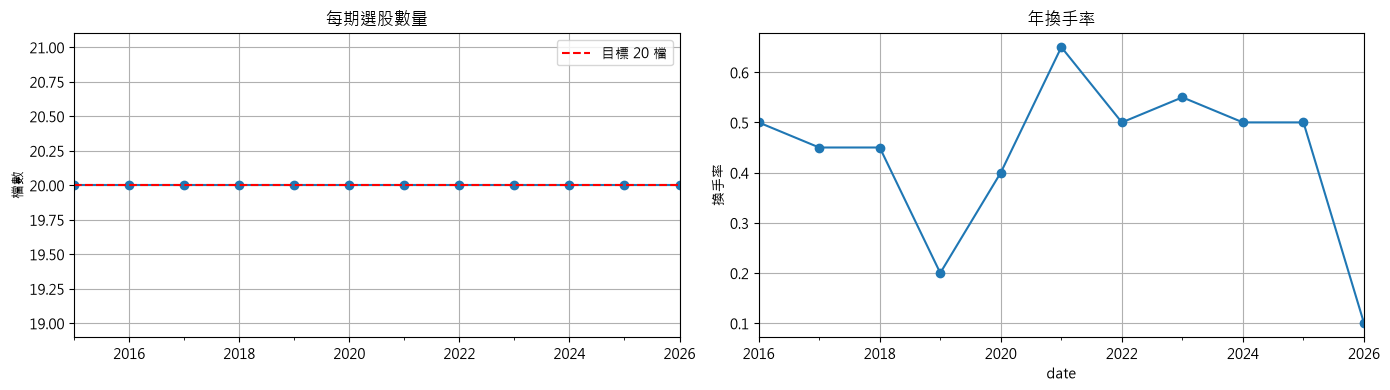

平均年換手率: 44%


In [13]:
# ── 7-A  覆蓋率 & 換手率 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts.plot(ax=axes[0], marker='o', title='每期選股數量', ylabel='檔數', grid=True)
axes[0].axhline(N_STOCKS, color='r', ls='--', label=f'目標 {N_STOCKS} 檔'); axes[0].legend()
prev, tv = set(), []
for d in sorted(stock_list_by_date):
    cur = set(stock_list_by_date[d])
    if prev: tv.append({'date': d, 'turnover': len(prev - cur)/len(prev)})
    prev = cur
tv_df = pd.DataFrame(tv).set_index('date')
tv_df['turnover'].plot(ax=axes[1], marker='o', title='年換手率', ylabel='換手率', grid=True)
plt.tight_layout(); plt.show()
print(f'平均年換手率: {tv_df["turnover"].mean():.0%}')

In [14]:
# ── 7-B  訊號強度：iB/M vs 純 B/M 分位多空（無摩擦，n_q=5）──────
def monthly_returns(price_daily):
    '''由「日頻」還原報酬複利成月報酬 wide（index=Period[M], col=coid）。
    注意：須傳日頻 price_raw，不可傳已抽月底的 price_monthly（否則只取單日報酬）。'''
    d = price_daily.copy(); d['ym'] = d['mdate'].dt.to_period('M')
    d['gross'] = 1 + d['ROI'].fillna(0)/100.0
    return (d.groupby(['coid', 'ym'])['gross'].prod() - 1).unstack(0).sort_index()

def quantile_ls(fac_df, col, R, n_q=5):
    f = fac_df[['coid', 'avail_date', col]].rename(columns={col: 'score', 'avail_date': 'date'})
    f['ym'] = f['date'].dt.to_period('M')
    sp = f.sort_values('date').groupby(['coid', 'ym'])['score'].last().unstack(0)
    months = R.index; months = months[(months >= pd.Period('2015-01', 'M')) & (months <= pd.Period('2025-05', 'M'))]
    sp = sp.reindex(months).ffill(limit=14); cal, ics = {}, []
    for i, m in enumerate(months):
        s = sp.loc[m].dropna()
        if len(s) < n_q*10: continue
        if i+1 < len(months):
            ic = s.rank().corr(R.loc[months[i+1]].reindex(s.index).rank())
            if np.isfinite(ic): ics.append(ic)
        q = pd.qcut(s.rank(method='first'), n_q, labels=False); j = i+1
        if j >= len(months): break
        ls = R.loc[months[j]].reindex(s.index[q==n_q-1]).mean() - R.loc[months[j]].reindex(s.index[q==0]).mean()
        if np.isfinite(ls): cal[months[j]] = ls
    ls = pd.Series(cal).sort_index()
    return dict(年化=round(ls.mean()*12*100, 2), t=round(ls.mean()/(ls.std(ddof=1)/np.sqrt(len(ls))), 2),
                Sharpe=round(ls.mean()/ls.std(ddof=1)*np.sqrt(12), 2), IC=round(np.mean(ics), 4))
R = monthly_returns(price_raw)   # 用日頻 price_raw 複利成月報酬（非 price_monthly）
res = pd.DataFrame([{'因子': '純 B/M', **quantile_ls(fac, 'bm', R)},
                    {'因子': 'iB/M(無形調整)', **quantile_ls(fac, 'ibm', R)}])
print('無摩擦分位多空（2015–2024）：'); res

無摩擦分位多空（2015–2024）：


,因子,年化,t,Sharpe,IC
0,純 B/M,9.15,2.81,0.88,0.0401
1,iB/M(無形調整),10.99,3.71,1.16,0.0272


---
## 8｜Zipline 回測（TQuant Lab）

In [15]:
# ── 8-A  匯入股價資料（+ 基準 IR0001）─────────────────────────
from zipline.data.run_ingest import simple_ingest
all_selected = sorted(set(t for picks in stock_list_by_date.values() for t in picks))
ingest_pool = all_selected + ['IR0001']
simple_ingest(name='tquant', tickers=ingest_pool,
              start_date=START_DATE.replace('-', ''), end_date=END_DATE.replace('-', ''))
print(f'ingest 完成：{len(ingest_pool)} 檔（含 IR0001）')

Now ingesting data.


End of ingesting tquant.
Please call function `get_bundle(start_dt = pd.Timestamp('20150601', tz = 'utc'),end_dt = pd.Timestamp('20260531' ,tz = 'utc'))` in `zipline.data.data_portal` to check data.
Currently used TEJ API key call quota 699/100000 (0.7%)
Currently used TEJ API key data quota 72331597/10000000 (723.32%)
ingest 完成：81 檔（含 IR0001）


In [16]:
# ── 8-B  換股日與權重（年度 6 月；等權 或 反波動率）──────────
VOL = R.rolling(VOL_LOOKBACK, min_periods=6).std()          # 尾隨月報酬波動（反波動率加權用）
def make_weights(picks, sig_year):
    picks = [str(t) for t in picks]
    if not picks:
        return {}
    if WEIGHTING == 'equal':
        return {t: 1.0/len(picks) for t in picks}
    may_p = pd.Period(f'{sig_year}-05', 'M')                 # 訊號日（5 月底）尾隨波動
    v = VOL.loc[may_p].reindex(picks) if may_p in VOL.index else pd.Series(np.nan, index=picks)
    iv = (1.0/v).replace([np.inf, -np.inf], np.nan)
    iv = iv.fillna(iv.median())                              # 缺波動者給中位數
    w = iv/iv.sum()
    return w.to_dict()

rebal_map, weight_map = {}, {}
for sig, picks in stock_list_by_date.items():
    rebal_date = pd.Timestamp(sig.year, REBAL_MONTH, 1)     # 訊號年的 6 月換倉
    rebal_map[rebal_date] = [str(t) for t in picks]
    weight_map[rebal_date] = make_weights(picks, sig.year)
print(f'年度換股次數: {len(rebal_map)} | 加權={WEIGHTING} | 首次: {min(rebal_map).date()}')

年度換股次數: 12 | 加權=invvol | 首次: 2015-06-01


In [17]:
# ── 8-C  Zipline 策略（依 weight_map 加權、年度再平衡）─────────
from zipline.api import (order_target_percent, set_commission, set_slippage,
    record, schedule_function, date_rules, time_rules, symbol, set_benchmark,
    cancel_order, get_open_orders)
from zipline.finance import slippage
from zipline.finance.commission import Custom_TW_Commission

def initialize(context):
    set_commission(Custom_TW_Commission(tax=0.003, discount=0.35, min_trade_cost=20.0))  # 台股手續費折0.35+證交稅0.3%
    set_slippage(slippage.NoSlippage())
    set_benchmark(symbol('IR0001'))                        # 含息報酬指數
    context.target_weights = {}
    schedule_function(rebalance, date_rules.month_start(), time_rules.market_open())

def _can_load(t):
    try: symbol(t); return True
    except Exception: return False

def before_trading_start(context, data):
    ym = (data.current_dt.year, data.current_dt.month)
    context.target_weights = {}
    for rebal_date, picks in rebal_map.items():
        if (rebal_date.year, rebal_date.month) == ym:
            wts = weight_map.get(rebal_date, {})
            for t in picks:
                if _can_load(t) and t in wts:
                    context.target_weights[symbol(t)] = wts[t]
            break

def rebalance(context, data):
    target = context.target_weights
    if not target:
        return
    for asset, orders in get_open_orders().items():
        for o in orders: cancel_order(o)
    for pos in context.portfolio.positions:                # 清倉不在名單者
        if pos not in target:
            order_target_percent(pos, 0)
    for asset, w in target.items():                         # 依權重買進名單
        if data.can_trade(asset):
            order_target_percent(asset, w)
    # 註：本函式內不 record 持倉數。order_target_percent 只是掛單、當日收盤才成交，
    #     此刻的 context.portfolio.positions 仍是「下單前」的舊部位；且本函式只在調倉月執行，
    #     record 出來的序列會變成「首年 0 檔、次年起才 20 檔」的假象。
    #     每日真實持倉一律用 Zipline 內建的 perf['longs_count']（見 9-A 平均持倉數）。
    log.info(f'{data.current_dt.date()} 年度調倉 {len(target)} 檔')

def analyze(context, perf):
    fig, ax = plt.subplots(figsize=(14, 5.5))
    cum = (1+perf['returns']).cumprod()-1; bm = (1+perf['benchmark_return']).cumprod()-1
    cum.plot(ax=ax, label='iValue_TW（iB/M v2 反波動率 N=20）', lw=2, color='#2E86AB')
    bm.plot(ax=ax, label='IR0001 含息報酬指數', lw=1.5, alpha=.7, color='#A23B72')
    ax.set_title(f"累積報酬 vs 含息基準（{perf.index[0]:%Y-%m-%d} ~ {perf.index[-1]:%Y-%m-%d}）",
                 fontweight='bold')
    ax.set_ylabel('累積報酬率'); ax.set_xlabel('')
    ax.legend(); ax.grid(True, alpha=.3); ax.axhline(0, color='k', lw=.8, ls='--', alpha=.5)
    plt.tight_layout(); plt.show()
print('策略函數定義完成（依 weight_map 加權、年度再平衡）')

策略函數定義完成（依 weight_map 加權、年度再平衡）


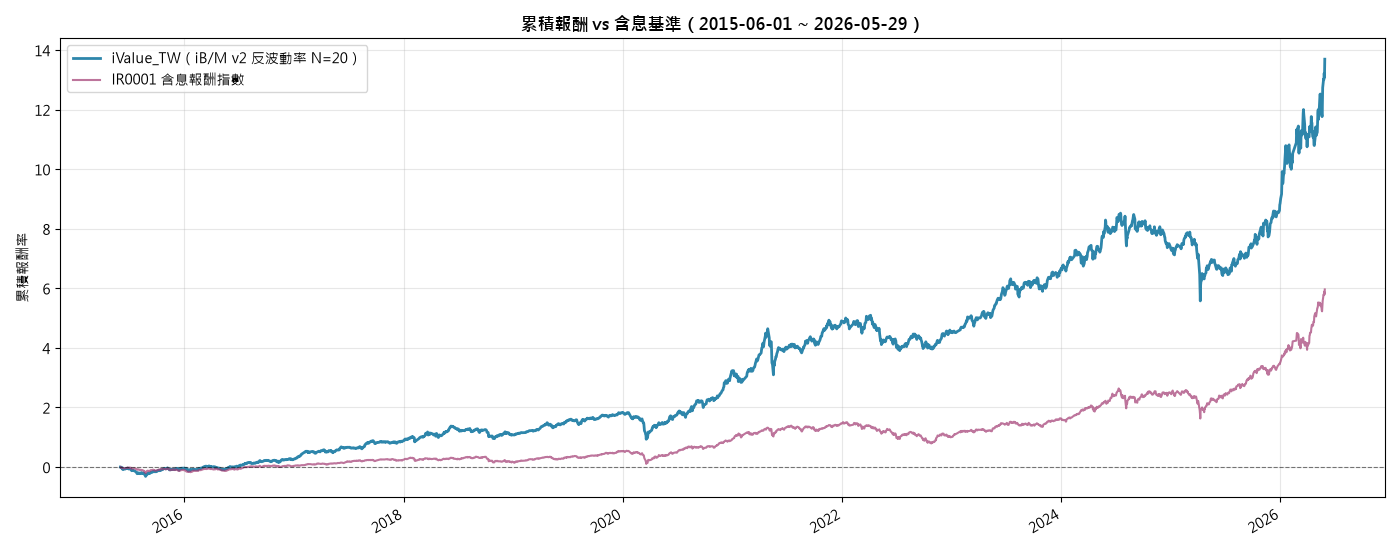

回測完成


In [18]:
# ── 8-D  執行回測 ─────────────────────────────────────────────
from zipline import run_algorithm
results = run_algorithm(
    start=pd.Timestamp(START_DATE, tz='utc'), end=pd.Timestamp(END_DATE, tz='utc'),
    initialize=initialize, before_trading_start=before_trading_start, analyze=analyze,
    bundle='tquant', capital_base=CAPITAL_BASE)
print('回測完成')

---
## 9｜績效摘要

In [19]:
total_ret  = (results['portfolio_value'].iloc[-1]/CAPITAL_BASE - 1)*100
bm_ret     = results['benchmark_period_return'].iloc[-1]*100
r = results['returns']; yrs = (results.index[-1]-results.index[0]).days/365.25
cagr = (results['portfolio_value'].iloc[-1]/CAPITAL_BASE)**(1/yrs)-1
max_dd = results['max_drawdown'].min()*100
sharpe = results['sharpe'].iloc[-1]
avg_pos = results['longs_count'].mean()   # 每日實際持倉（非 record 的 num_positions）
print('='*44)
print(f'  策略總報酬   : {total_ret:>8.2f}%')
print(f'  年化報酬CAGR : {cagr*100:>8.2f}%')
print(f'  基準總報酬   : {bm_ret:>8.2f}%')
print(f'  超額(總)     : {total_ret-bm_ret:>8.2f}%')
print(f'  最大回撤     : {max_dd:>8.2f}%')
print(f'  夏普比率     : {sharpe:>8.2f}')
print(f'  平均持倉數   : {avg_pos:>8.1f} 檔')
print('='*44)
results.to_csv('iValue_TW_results.csv'); print('詳細結果已存 iValue_TW_results.csv')

  策略總報酬   :  1369.31%
  年化報酬CAGR :    27.69%
  基準總報酬   :   596.20%
  超額(總)     :   773.11%
  最大回撤     :   -31.72%
  夏普比率     :     1.36
  平均持倉數   :     20.0 檔
詳細結果已存 iValue_TW_results.csv


Start date,2015-06-01
End date,2026-05-29
Total months,127
,Backtest
Annual return,28.725%
Cumulative returns,1369.309%
Annual volatility,20.081%
Sharpe ratio,1.36
Calmar ratio,0.91
Stability,0.97
Max drawdown,-31.722%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,31.72,2020-01-02,2020-03-19,2020-07-06,120
1,31.36,2015-06-01,2015-08-24,2016-03-04,187
2,30.94,2024-07-17,2025-04-09,2025-12-08,340
3,27.43,2021-04-28,2021-05-17,2021-11-08,134
4,19.49,2022-04-06,2022-07-12,2023-04-12,248


Top 10 long positions of all time,max
sid,
2838,23.42%
2908,21.51%
2345,17.61%
2337,16.54%
2388,16.35%
5512,14.55%
3481,14.52%
2371,14.13%
2332,13.42%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
2838,23.42%
2908,21.51%
2345,17.61%
2337,16.54%
2388,16.35%
5512,14.55%
3481,14.52%
2371,14.13%
2332,13.42%


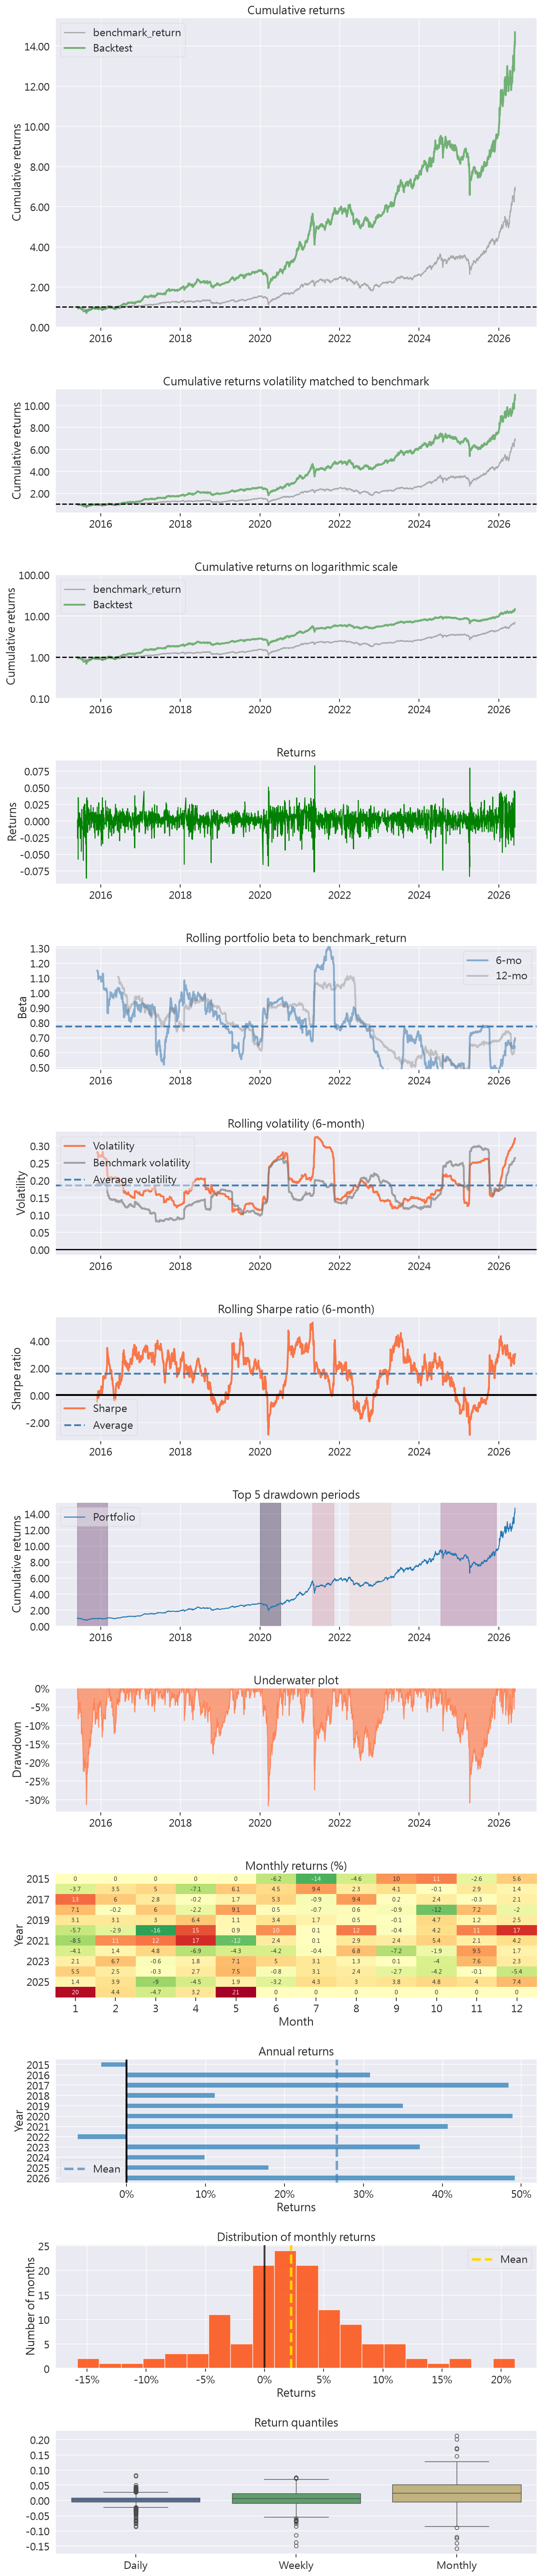

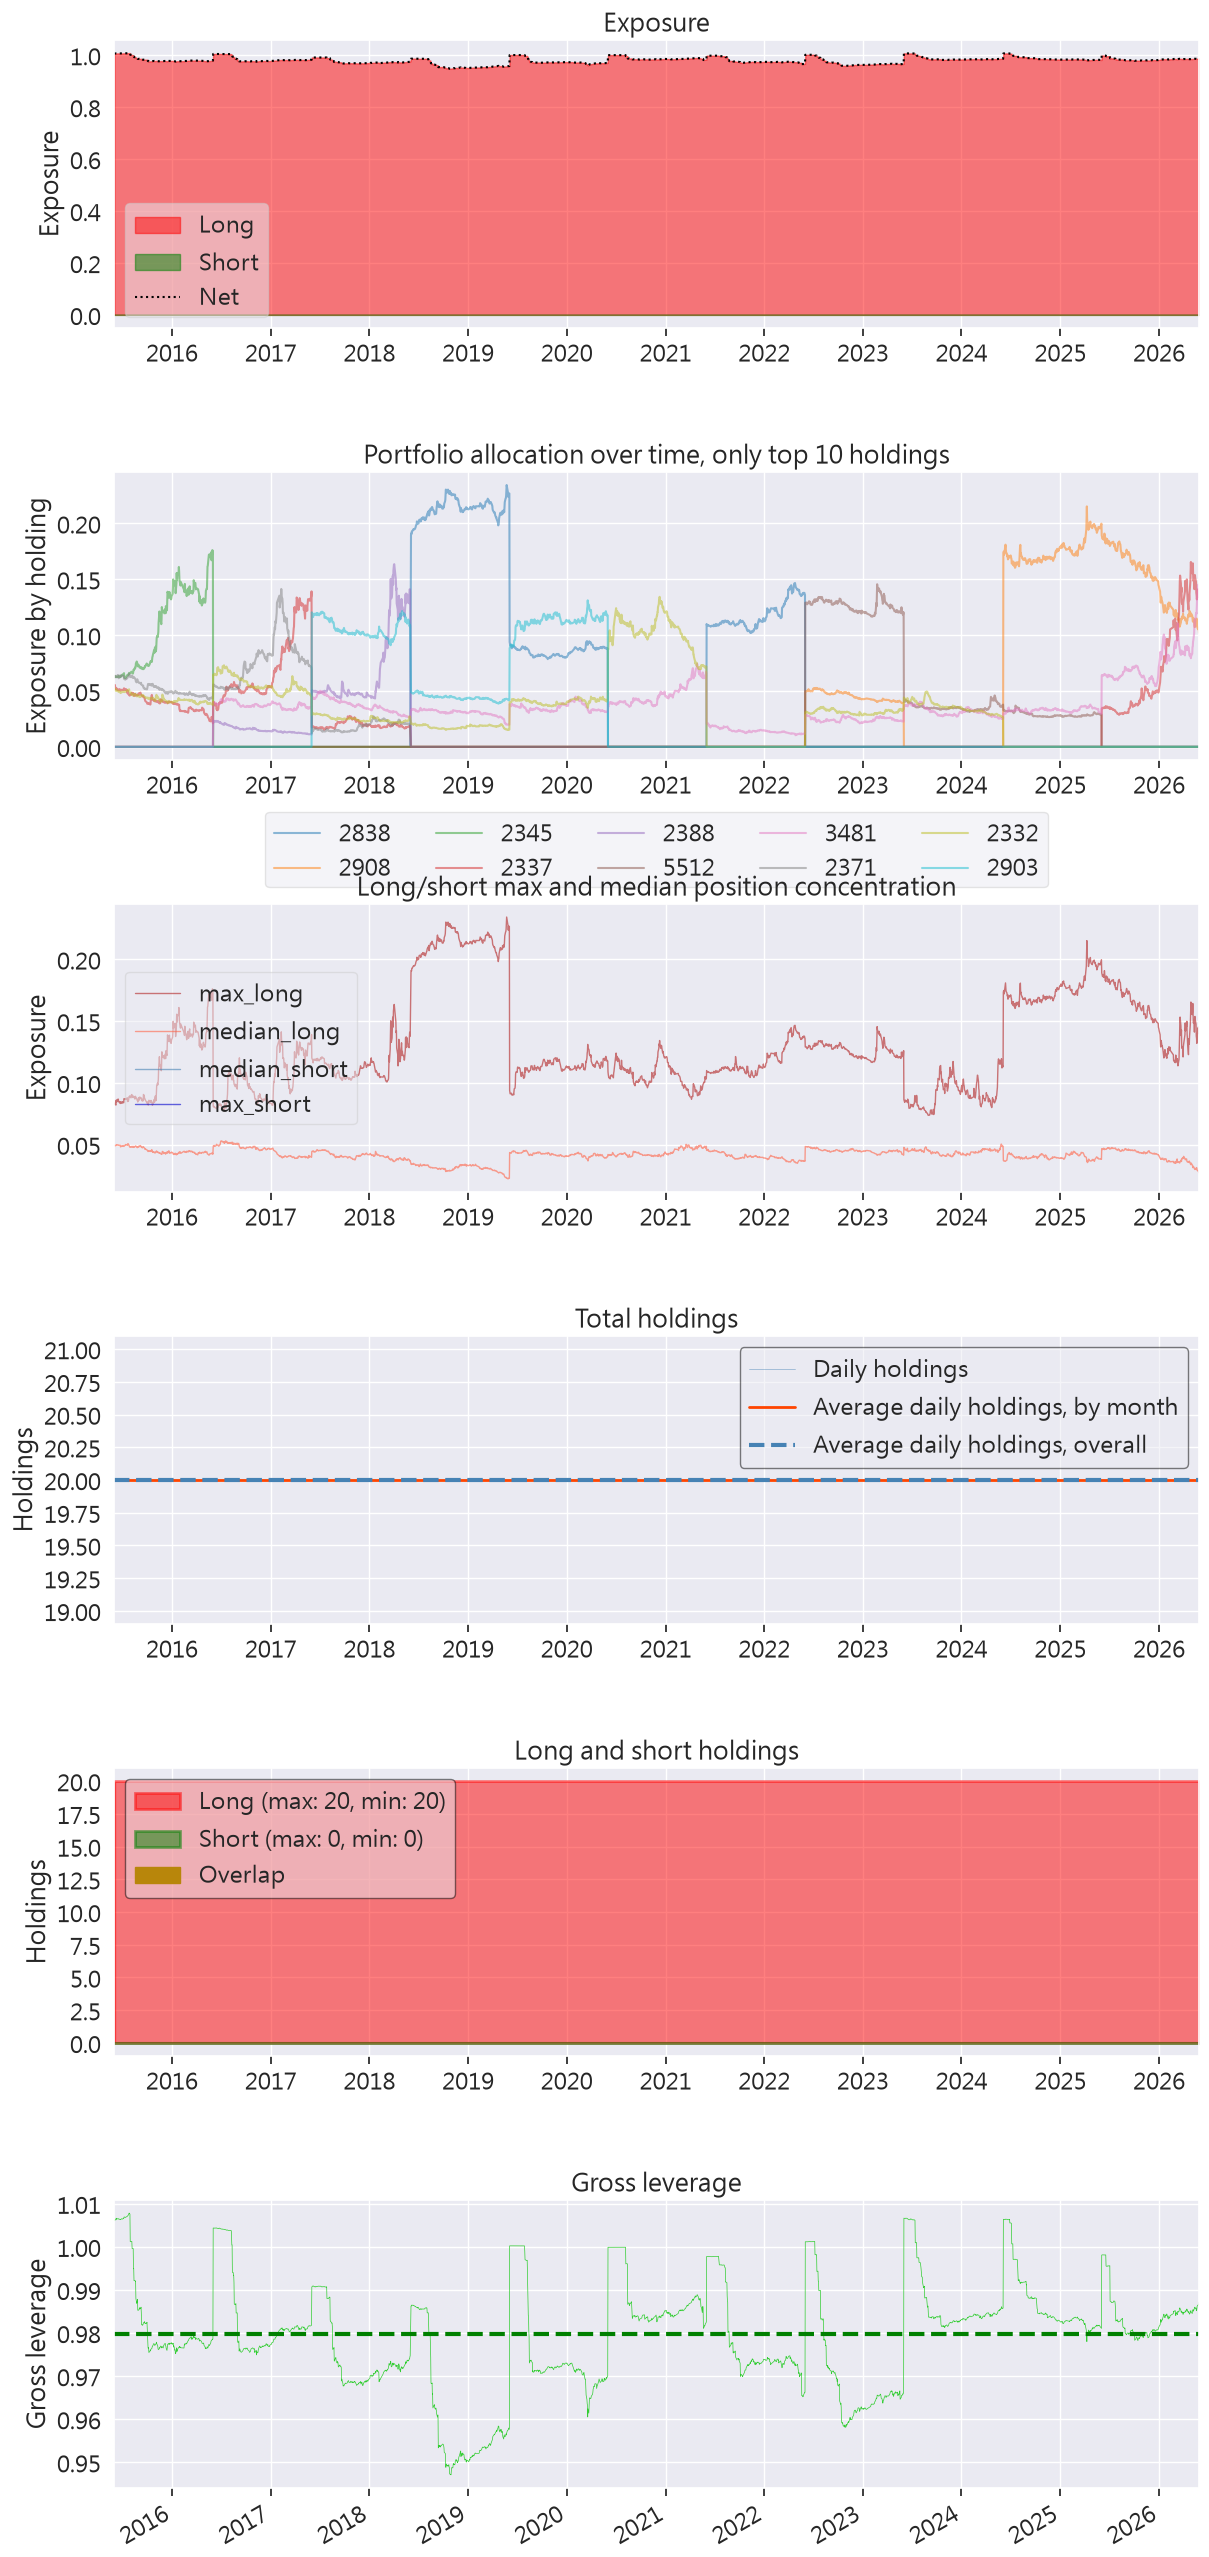

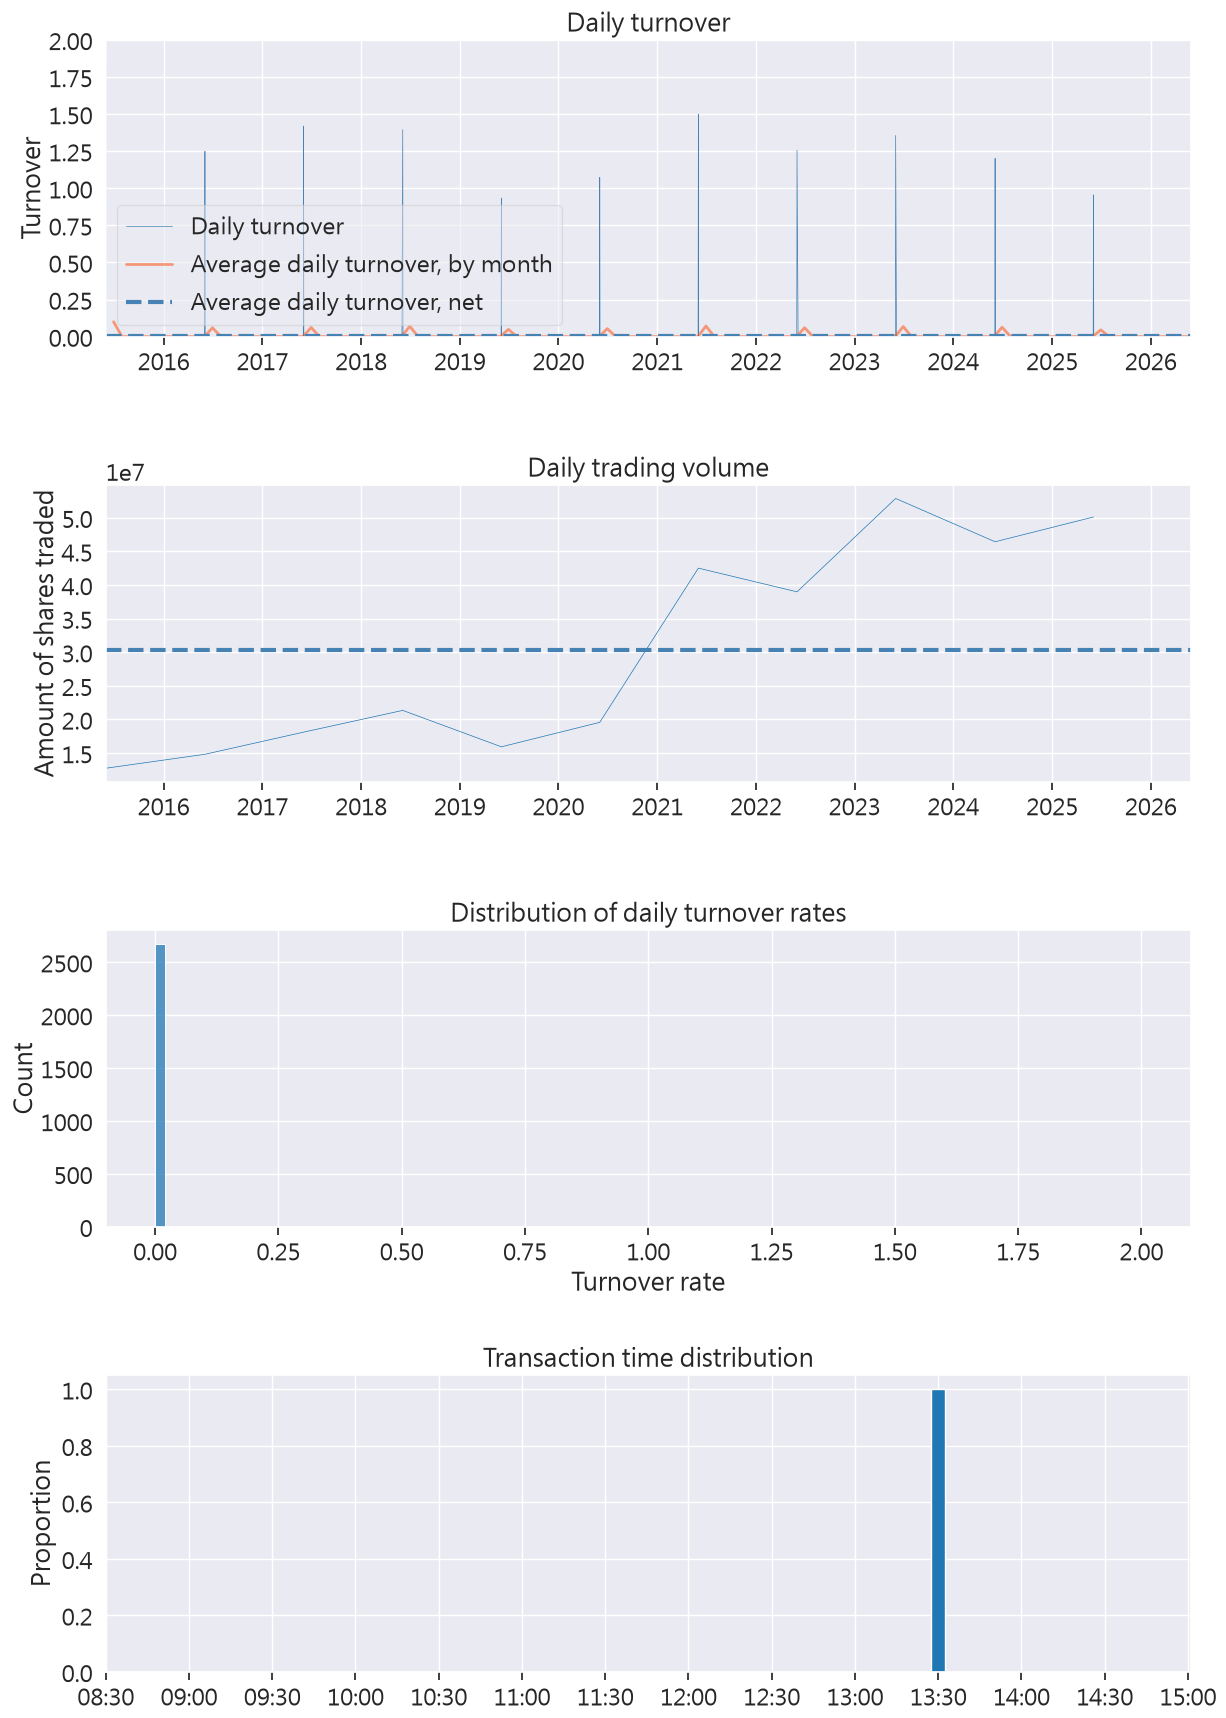

In [20]:
# ── Pyfolio 完整分析（選用）──────────────────────────────────
try:
    import pyfolio as pf
    from pyfolio.utils import extract_rets_pos_txn_from_zipline
    returns, positions, transactions = extract_rets_pos_txn_from_zipline(results)
    pf.tears.create_full_tear_sheet(returns=returns, positions=positions,
        transactions=transactions, benchmark_rets=results.benchmark_return)
except ImportError:
    print('未安裝 pyfolio，略過完整分析')